# 0. Cellule de rechargement

In [1]:
# from pyspark.sql import SparkSession
# from pyspark.ml.feature import StringIndexer, VectorAssembler
# from pyspark.ml.classification import RandomForestClassifier
# from pyspark.ml.classification import RandomForestClassificationModel
# import pandas as pd
#
# # Spark session
# spark = SparkSession.builder.appName("NetSentinel").getOrCreate()
#
# # Charger le parquet
# df_final = spark.read.parquet("../data/processed/df_final.parquet")
# train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)
#
# # Recréer l'indexer pour avoir le mapping labels
# df_clean = spark.read.parquet("../data/processed/df_final.parquet")
# indexer = StringIndexer(inputCol="label", outputCol="label_index")
#
# # Charger le modèle sauvegardé
# model = RandomForestClassificationModel.load("../data/model_rf")
#
# # Recréer les prédictions
# predictions = model.transform(test_df)
#
# print("Tout rechargé")

# 1. Initialisation de la session Spark

In [2]:
# initialisation de la session Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("NetSentinel - Batch Analysis").config("spark.driver.memory", "25g").getOrCreate()
print(spark.version)

3.5.5


26/03/27 14:07:53 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


# 2. Concaténation des différents .csv

In [3]:
# importation de tous les .csv
import os

data_path = "../data"
df = spark.read.csv(data_path, header=True, inferSchema=True)

print(f"Nombre de lignes : {df.count()}")
print(f"Nombre de colonnes : {len(df.columns)}")

df.printSchema()

Nombre de lignes : 2608824
Nombre de colonnes : 122
root
 |-- flow_id: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- src_ip: string (nullable = true)
 |-- src_port: string (nullable = true)
 |-- dst_ip: string (nullable = true)
 |-- dst_port: string (nullable = true)
 |-- protocol: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- packets_count: string (nullable = true)
 |-- fwd_packets_count: string (nullable = true)
 |-- bwd_packets_count: string (nullable = true)
 |-- total_payload_bytes: string (nullable = true)
 |-- fwd_total_payload_bytes: string (nullable = true)
 |-- bwd_total_payload_bytes: string (nullable = true)
 |-- payload_bytes_max: string (nullable = true)
 |-- payload_bytes_min: string (nullable = true)
 |-- payload_bytes_mean: string (nullable = true)
 |-- payload_bytes_std: string (nullable = true)
 |-- payload_bytes_variance: string (nullable = true)
 |-- fwd_payload_bytes_max: double (nullable = true)
 |-- fwd_payload_by

### Vérification du déséquilibre des classes

- Le dataset source BCCC-CIC-IDS-2017 contient 2.6M de connexions réseau réparties sur 15 classes, Après analyse de la distribution des labels, nous avons décidé de filtrer le dataset pour ne garder que les 4 classes les plus représentées, afin de limiter le déséquilibre entre classes tout en conservant les types d'attaques les plus courants en entreprise

**info** : Note : le dataset source complet (2GB) est conservé et chargé intégralement par Spark —
le filtrage intervient uniquement en aval pour la phase d'entraînement du modèle.

In [4]:
df.groupBy("label").count().orderBy("count", ascending=False).show(truncate=False)

+-----------------+-------+
|label            |count  |
+-----------------+-------+
|Benign           |1786239|
|DoS_Hulk         |349240 |
|NULL             |170772 |
|Port_Scan        |161323 |
|DDoS_LOIT        |95733  |
|FTP-Patator      |9531   |
|DoS_GoldenEye    |8364   |
|DoS_Slowhttptest |6860   |
|SSH-Patator      |5949   |
|Botnet_ARES      |5508   |
|DoS_Slowloris    |5177   |
|Web_Brute_Force  |2734   |
|Web_XSS          |1358   |
|Web_SQL_Injection|24     |
|Heartbleed       |12     |
+-----------------+-------+



### Application des transformations citées ci-dessus

In [5]:
from pyspark.sql import functions as F

# définition des 10 labels qu'on veut garder
labels_conserved = [
    "Benign", "DoS_Hulk", "Port_Scan", "DDoS_LOIT",
    "FTP-Patator", "DoS_GoldenEye", "DoS_Slowhttptest",
    "SSH-Patator", "Botnet_ARES", "DoS_Slowloris"
]

# pour éviter le déséquilibre des classes, nous limitons le trafic normal a 100.000 lignes
benign_df = df.filter(F.col("label") == "Benign").limit(50000)

# pour éviter que les attaques avec peu de lignes soient écrasées nous allons également réduire Dos_Hulk + Port_Scan
dos_hulk_df = df.filter(F.col("label") == "DoS_Hulk").limit(50000)
port_scan_df = df.filter(F.col("label") == "Port_Scan").limit(50000)

# nous prenons toutes les attaques sauf le benign
attacks_df = df.filter(
    (F.col("label") != "Benign") &
    (F.col("label") != "DoS_Hulk") &
    (F.col("label") != "Port_Scan") &
    (F.col("label").isin(labels_conserved))
)

# nous collons les 2 df ensemble, le premier qui est limité à 100.000 et l'autre qui contient les attaques uniquement
df_balanced = benign_df.union(dos_hulk_df).union(port_scan_df).union(attacks_df)

# vérification - affiche le nombre de lignes par label
df_balanced.groupBy("label").count().orderBy("count", ascending=False).show()

+----------------+-----+
|           label|count|
+----------------+-----+
|       DDoS_LOIT|95733|
|          Benign|50000|
|        DoS_Hulk|50000|
|       Port_Scan|50000|
|     FTP-Patator| 9531|
|   DoS_GoldenEye| 8364|
|DoS_Slowhttptest| 6860|
|     SSH-Patator| 5949|
|     Botnet_ARES| 5508|
|   DoS_Slowloris| 5177|
+----------------+-----+



# 3. Exploration & Nettoyage des données

### 3.1 suppression des colonnes inutiles pour le ML

## Sélection des features

Après analyse des 116 features disponibles, nous avons décidé de réduire le nombre de features
à une quarantaine. Cette décision est motivée par deux raisons principales :

1. **Réduire le risque d'overfitting** — plus on a de features, plus le modèle risque d'apprendre
des patterns spécifiques au train set qui ne se généralisent pas bien.

2. **Réduire la consommation mémoire** — avec moins de features, on peut se permettre plus
d'arbres et plus de profondeur, ce qui améliore les performances globales.

### Features conservées et pourquoi

**Ports (src_port, dst_port)** → utiles pour détecter FTP-Patator (port 21) et SSH-Patator (port 22).

**Volume et débit** (duration, packets_count, fwd/bwd_packets_count, total_payload_bytes, bytes_rate,
fwd/bwd_bytes_rate, packets_rate, fwd/bwd_packets_rate, down_up_rate) → très révélateurs des attaques
DoS/DDoS qui génèrent un volume anormal de trafic.

**Taille des paquets** (payload_bytes_max/mean/std, fwd/bwd_payload_bytes_mean/std, avg_segment_size)
→ les attaques ont souvent des tailles de paquets très uniformes ou anormalement petites/grandes.

**Flags TCP** (fin, psh, urg, syn, ack, rst et leurs équivalents fwd) → critiques pour détecter les
attaques. Un SYN flood génère des milliers de flags SYN, un RST flood des milliers de RST.

**Timing entre paquets IAT** (packets_IAT_mean/std/max/min, fwd/bwd_packets_IAT_mean/std) → les
attaques automatisées ont des temps entre paquets très réguliers contrairement au trafic humain.

**Fenêtres TCP** (fwd/bwd_init_win_bytes) → la taille de fenêtre initiale est anormale lors d'un
SYN flood.

### Features supprimées et pourquoi

**Bulk features** (avg_fwd/bwd_bytes_per_bulk, fwd/bwd_bulk_state_count, etc.) → ces features
mesurent les transferts de données en rafale. Elles sont peu discriminantes pour nos types
d'attaques et très corrélées avec les features de volume déjà conservées.

**Header bytes** (total_header_bytes, max/min/mean/std_header_bytes et leurs équivalents fwd/bwd)
→ fortement corrélés avec les features de payload déjà conservées. Redondant.

**Flags ECE et CWR** (ece_flag_counts, cwr_flag_counts et leurs équivalents) → ces flags de
congestion réseau apparaissent très rarement et n'apportent pas d'information discriminante
pour nos classes d'attaques.

**Subflow features** (subflow_fwd/bwd_packets/bytes) → redondants avec packets_count et
total_payload_bytes déjà conservés.

**Active/Idle features** (active_min/max/mean/std, idle_min/max/mean/std) → ces features
mesurent les périodes d'activité et d'inactivité du flux. Peu pertinentes pour distinguer
les types d'attaques dans notre dataset.

In [6]:
cols_to_drop = [
    # identifiants inutiles
    "flow_id", "timestamp", "src_ip", "dst_ip",
    # header bytes redondants
    "total_header_bytes", "max_header_bytes", "min_header_bytes", "mean_header_bytes", "std_header_bytes",
    "fwd_total_header_bytes", "fwd_max_header_bytes", "fwd_min_header_bytes", "fwd_mean_header_bytes", "fwd_std_header_bytes",
    "bwd_total_header_bytes", "bwd_max_header_bytes", "bwd_min_header_bytes", "bwd_mean_header_bytes", "bwd_std_header_bytes",
    # bulk features redondants
    "avg_fwd_bytes_per_bulk", "avg_fwd_packets_per_bulk", "avg_fwd_bulk_rate",
    "avg_bwd_bytes_per_bulk", "avg_bwd_packets_bulk_rate", "avg_bwd_bulk_rate",
    "fwd_bulk_state_count", "fwd_bulk_total_size", "fwd_bulk_per_packet", "fwd_bulk_duration",
    "bwd_bulk_state_count", "bwd_bulk_total_size", "bwd_bulk_per_packet", "bwd_bulk_duration",
    # flags peu discriminants
    "ece_flag_counts", "cwr_flag_counts", "fwd_ece_flag_counts", "fwd_cwr_flag_counts",
    "bwd_fin_flag_counts", "bwd_psh_flag_counts", "bwd_urg_flag_counts", "bwd_ece_flag_counts",
    "bwd_syn_flag_counts", "bwd_ack_flag_counts", "bwd_cwr_flag_counts", "bwd_rst_flag_counts",
    # active/idle peu pertinents
    "active_min", "active_max", "active_mean", "active_std",
    "idle_min", "idle_max", "idle_mean", "idle_std",
    # subflow redondants
    "subflow_fwd_packets", "subflow_bwd_packets", "subflow_fwd_bytes", "subflow_bwd_bytes",
    # payload redondants
    "payload_bytes_min", "payload_bytes_variance",
    "fwd_payload_bytes_max", "fwd_payload_bytes_min", "fwd_payload_bytes_variance",
    "bwd_payload_bytes_max", "bwd_payload_bytes_min", "bwd_payload_bytes_variance",
    # IAT redondants
    "packet_IAT_total", "fwd_packets_IAT_max", "fwd_packets_IAT_min", "fwd_packets_IAT_total",
    "bwd_packets_IAT_max", "bwd_packets_IAT_min", "bwd_packets_IAT_total",
    # fwd flags redondants
    "fwd_fin_flag_counts", "fwd_psh_flag_counts", "fwd_urg_flag_counts",
]

df_clean = df_balanced.drop(*cols_to_drop)
print(f"Colonnes restantes : {len(df_clean.columns)}")

Colonnes restantes : 47


### 3.2 affichage des types de chaque colonne

In [7]:
for col, dtype in df_clean.dtypes:
    print(f"{col} : {dtype}")

src_port : string
dst_port : string
protocol : string
duration : string
packets_count : string
fwd_packets_count : string
bwd_packets_count : string
total_payload_bytes : string
fwd_total_payload_bytes : string
bwd_total_payload_bytes : string
payload_bytes_max : string
payload_bytes_mean : string
payload_bytes_std : string
fwd_payload_bytes_mean : double
fwd_payload_bytes_std : double
bwd_payload_bytes_mean : double
bwd_payload_bytes_std : double
fwd_avg_segment_size : double
bwd_avg_segment_size : double
avg_segment_size : double
fwd_init_win_bytes : int
bwd_init_win_bytes : int
bytes_rate : double
fwd_bytes_rate : double
bwd_bytes_rate : double
packets_rate : double
bwd_packets_rate : double
fwd_packets_rate : double
down_up_rate : double
fin_flag_counts : int
psh_flag_counts : int
urg_flag_counts : int
syn_flag_counts : int
ack_flag_counts : int
rst_flag_counts : int
fwd_syn_flag_counts : int
fwd_ack_flag_counts : int
fwd_rst_flag_counts : int
packets_IAT_mean : double
packet_IAT_s

### 3.3 conversion des dtypes nécessaire pour le ML
- Nous allons convertir les types (string) en types (double)

In [8]:
# liste des colonnes à convertir
string_to_double = [
    "src_port", "dst_port", "duration", "packets_count",
    "fwd_packets_count", "bwd_packets_count", "total_payload_bytes",
    "fwd_total_payload_bytes", "bwd_total_payload_bytes",
    "payload_bytes_max", "payload_bytes_mean", "payload_bytes_std"
]

for col_name in string_to_double:
    df_clean = df_clean.withColumn(col_name, F.col(col_name).cast("double"))

for col, dtype in df_clean.dtypes:
    print(f"{col} : {dtype}")

src_port : double
dst_port : double
protocol : string
duration : double
packets_count : double
fwd_packets_count : double
bwd_packets_count : double
total_payload_bytes : double
fwd_total_payload_bytes : double
bwd_total_payload_bytes : double
payload_bytes_max : double
payload_bytes_mean : double
payload_bytes_std : double
fwd_payload_bytes_mean : double
fwd_payload_bytes_std : double
bwd_payload_bytes_mean : double
bwd_payload_bytes_std : double
fwd_avg_segment_size : double
bwd_avg_segment_size : double
avg_segment_size : double
fwd_init_win_bytes : int
bwd_init_win_bytes : int
bytes_rate : double
fwd_bytes_rate : double
bwd_bytes_rate : double
packets_rate : double
bwd_packets_rate : double
fwd_packets_rate : double
down_up_rate : double
fin_flag_counts : int
psh_flag_counts : int
urg_flag_counts : int
syn_flag_counts : int
ack_flag_counts : int
rst_flag_counts : int
fwd_syn_flag_counts : int
fwd_ack_flag_counts : int
fwd_rst_flag_counts : int
packets_IAT_mean : double
packet_IAT_s

### 3.4 vérification des valeurs

In [9]:
# - F.col(c).isNull() → retourne True/False pour chaque ligne
# - .cast("int") → convertit True=1, False=0
# - F.sum() → additionne tous les 1 = nombre total de nulls
# - .alias(c) → renomme la colonne résultante avec le nom de la colonne originale

null_counts = df_clean.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c)
    for c in df_clean.columns
])

# affichage vertical pour plus de clarté
null_counts.show(vertical=True)

26/03/27 14:08:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


-RECORD 0----------------------
 src_port                | 0   
 dst_port                | 0   
 protocol                | 0   
 duration                | 0   
 packets_count           | 0   
 fwd_packets_count       | 0   
 bwd_packets_count       | 0   
 total_payload_bytes     | 0   
 fwd_total_payload_bytes | 0   
 bwd_total_payload_bytes | 0   
 payload_bytes_max       | 0   
 payload_bytes_mean      | 0   
 payload_bytes_std       | 0   
 fwd_payload_bytes_mean  | 0   
 fwd_payload_bytes_std   | 0   
 bwd_payload_bytes_mean  | 0   
 bwd_payload_bytes_std   | 0   
 fwd_avg_segment_size    | 0   
 bwd_avg_segment_size    | 0   
 avg_segment_size        | 0   
 fwd_init_win_bytes      | 0   
 bwd_init_win_bytes      | 0   
 bytes_rate              | 0   
 fwd_bytes_rate          | 0   
 bwd_bytes_rate          | 0   
 packets_rate            | 0   
 bwd_packets_rate        | 0   
 fwd_packets_rate        | 0   
 down_up_rate            | 0   
 fin_flag_counts         | 0   
 psh_fla

**info** : nous décidons de supprimer la colonne 'protocol' parce qu'elle contenait des valeurs non numériques (TCP, UDP) qui sont devenues nulle après la conversion en double, presque l'entièreté de la colonne est vide, de plus le protocole est indirectement représenté par les flags TCP donc nous décidons de supprimer cette colonne

In [10]:
# suppression de la colonne 'protocol'
df_clean = df_clean.drop("protocol")

# vérification
print(f"Colonnes restantes : {len(df_clean.columns)}")

Colonnes restantes : 46


### 3.5 remplacer les valeurs infinies par null

- quand spark divise par 0 il génère des inf ou -inf et le ML ne sait pas gérer ça, nous remplaçons donc les valeurs inf et -inf par null

In [11]:
import math

# nous récupérons toutes les colonnes doubles
double_cols = [c for c, t in df_clean.dtypes if t == "double"]

# pour chaque colonne double, on remplace par inf, -inf par null
for c in double_cols:
    df_clean = df_clean.withColumn(c,
        F.when(F.col(c) == float("inf"), None)
        .when(F.col(c) == float("-inf"), None)
        .otherwise(F.col(c))
    )

print(f"Valeurs infinies remplacées par null OK !")

Valeurs infinies remplacées par null OK !


In [12]:
# maintenant que certaines valeurs ont été remplacées par NULL, nous allons les supprimer

df_clean = df_clean.dropna()

# vérification
print(f"Lignes restantes : {df_clean.count()}")
df_clean.groupBy("label").count().orderBy("count", ascending=False).show()

Lignes restantes : 287122


+----------------+-----+
|           label|count|
+----------------+-----+
|       DDoS_LOIT|95733|
|          Benign|50000|
|        DoS_Hulk|50000|
|       Port_Scan|50000|
|     FTP-Patator| 9531|
|   DoS_GoldenEye| 8364|
|DoS_Slowhttptest| 6860|
|     SSH-Patator| 5949|
|     Botnet_ARES| 5508|
|   DoS_Slowloris| 5177|
+----------------+-----+



---
# 4. MACHINE LEARNING

### 4.1 encodage du label, on va remplacer le nom des attaques par des chiffres style label = 0, DDOS = 1 etc

In [13]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# utilisation de StringIndexer qui permet de transformer les labels texte en indice numériques
indexer = StringIndexer(inputCol="label", outputCol="label_index")
df_indexed = indexer.fit(df_clean).transform(df_clean)

# assembler toutes les features en un seul vecteur, parce que spark accepte uniquement 2 colonnes en entrée donc on met toutes les feat dans un vec
feature_cols = [c for c in df_indexed.columns if c not in ["label", "label_index"]]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_final = assembler.transform(df_indexed)

# split 80 / 20
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)

print(f"Train : {train_df.count()}")
print(f"Test : {test_df.count()}")

Train : 229655


Test : 57467


### 4.2 sauvegarde intermédiaire .parquet

In [14]:
# afin de respecter les bonnes pratiques (conseillées) nous allons sauvegarder nos étapes intermédiaires en parquet

df_final.write.parquet("../data/processed/df_final.parquet", mode="overwrite")
print("Sauvegarde Parquet OK !")

# pour reprendre à ce niveau, run : df_final = spark.read.parquet("../data/processed/df_final.parquet")

Sauvegarde Parquet OK !


In [15]:
df_final = spark.read.parquet("../data/processed/df_final.parquet")
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)

### 4.3 train du modèle (random forest)

In [16]:
# TEST DE PLUSIEURS MODELES

# from pyspark.ml.classification import RandomForestClassifier
# from pyspark.ml.evaluation import MulticlassClassificationEvaluator
#
# evaluator = MulticlassClassificationEvaluator(
#     labelCol="label_index",
#     predictionCol="prediction",
#     metricName="f1"
# )
#
# results = []
#
# for num_trees in [50, 100]:
#     for max_depth in [5, 8]:
#         print(f"Test : numTrees={num_trees}, maxDepth={max_depth}...")
#
#         rf = RandomForestClassifier(
#             numTrees=num_trees,
#             maxDepth=max_depth,
#             labelCol="label_index",
#             featuresCol="features",
#             seed=42
#         )
#
#         model_test = rf.fit(train_df)
#         preds = model_test.transform(test_df)
#         f1 = evaluator.evaluate(preds)
#
#         results.append({
#             "numTrees": num_trees,
#             "maxDepth": max_depth,
#             "f1": f1
#         })
#         print(f"  F1 = {f1:.4f}")
#
# print("\nRésultats :")
# for r in results:
#     print(r)

In [17]:
# meilleur modèle trouvé par le grid search : numTrees=50, maxDepth=8 -> F1=0.9666

from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    numTrees=90,
    maxDepth=7,
    labelCol="label_index",
    featuresCol="features",
    seed=42
)

print("Entraînement du meilleur modèle...")
model = rf.fit(train_df)
print("Modèle entraîné")

Entraînement du meilleur modèle...


26/03/27 14:11:38 WARN DAGScheduler: Broadcasting large task binary with size 1321.6 KiB
26/03/27 14:11:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/03/27 14:11:42 WARN TaskSetManager: Lost task 5.0 in stage 117.0 (TID 1120) (172.23.0.3 executor 0): java.lang.OutOfMemoryError: Java heap space
	at org.apache.spark.ml.tree.impl.DTStatsAggregator.<init>(DTStatsAggregator.scala:77)
	at org.apache.spark.ml.tree.impl.RandomForest$.$anonfun$findBestSplits$22(RandomForest.scala:651)
	at org.apache.spark.ml.tree.impl.RandomForest$.$anonfun$findBestSplits$22$adapted(RandomForest.scala:647)
	at org.apache.spark.ml.tree.impl.RandomForest$$$Lambda$3820/0x0000000840d06040.apply(Unknown Source)
	at scala.Array$.tabulate(Array.scala:418)
	at org.apache.spark.ml.tree.impl.RandomForest$.$anonfun$findBestSplits$21(RandomForest.scala:647)
	at org.apache.spark.ml.tree.impl.RandomForest$$$Lambda$3737/0x0000000841085040.apply(Unknown Source)
	at org.apache.spark.rdd.RDD.$anonfun$

Modèle entraîné


### 4.4 évaluation

In [18]:
# prédictions sur le test set
predictions = model.transform(test_df)

# évaluation -> on utilise la multi classe pour évaluer et non un 1 vs 1
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# accuracy
accuracy = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(predictions)

# précision
precisions = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(predictions)

# recall
recall = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(predictions)

# f1_score
f_score = MulticlassClassificationEvaluator(
    labelCol="label_index",
    predictionCol="prediction",
    metricName="f1"
).evaluate(predictions)

print(f"Accuracy : {accuracy}")
print(f"Précision : {precisions}")
print(f"Recall : {recall}")
print(f"F1-Score : {f_score}")

26/03/27 14:11:53 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/03/27 14:11:55 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/03/27 14:11:56 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/03/27 14:11:57 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


Accuracy : 0.966664921374592
Précision : 0.9688773253474651
Recall : 0.966664921374592
F1-Score : 0.9648269232954425


In [19]:
import pandas as pd
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# matrice de confusion
conf_matrix = predictions.groupBy("label_index", "prediction").count().orderBy("label_index", "prediction")

# conversion en pandas pour afficher
conf_df = conf_matrix.toPandas()

# Récupérer le mapping index -> nom d'attaque
labels = ["Benign", "DDoS_LOIT", "DoS_Hulk", "Port_Scan",
          "FTP-Patator", "DoS_GoldenEye", "DoS_Slowhttptest",
          "SSH-Patator", "Botnet_ARES", "DoS_Slowloris"]
print("Mapping :")
for i, l in enumerate(labels):
    print(f"  {i} → {l}")

print("\nMatrice de confusion brute :")
print(conf_df)

26/03/27 14:11:59 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
26/03/27 14:12:00 WARN DAGScheduler: Broadcasting large task binary with size 2037.7 KiB
26/03/27 14:12:01 WARN DAGScheduler: Broadcasting large task binary with size 2039.0 KiB


Mapping :
  0 → Benign
  1 → DDoS_LOIT
  2 → DoS_Hulk
  3 → Port_Scan
  4 → FTP-Patator
  5 → DoS_GoldenEye
  6 → DoS_Slowhttptest
  7 → SSH-Patator
  8 → Botnet_ARES
  9 → DoS_Slowloris

Matrice de confusion brute :
    label_index  prediction  count
0           0.0         0.0  19085
1           0.0         1.0     14
2           1.0         1.0   9780
3           1.0         2.0     98
4           1.0         5.0      2
5           1.0         6.0      1
6           1.0         9.0      7
7           2.0         1.0     14
8           2.0         2.0   9971
9           2.0         5.0      5
10          3.0         1.0     38
11          3.0         3.0  10044
12          3.0         8.0      2
13          4.0         1.0      1
14          4.0         2.0    326
15          4.0         4.0   1604
16          4.0         7.0      3
17          5.0         1.0    192
18          5.0         2.0    124
19          5.0         5.0   1378
20          5.0         6.0      1
21          5

26/03/27 14:12:01 WARN DAGScheduler: Broadcasting large task binary with size 2036.0 KiB


### Rappel -> prochaine étape :
- faire une matrice de confusion
- regardez, les features les plus importantes (faire quelques graphiques)
- quelques plots (distributions des attaques, métriques visuelle)
- faire le vrai dashboard

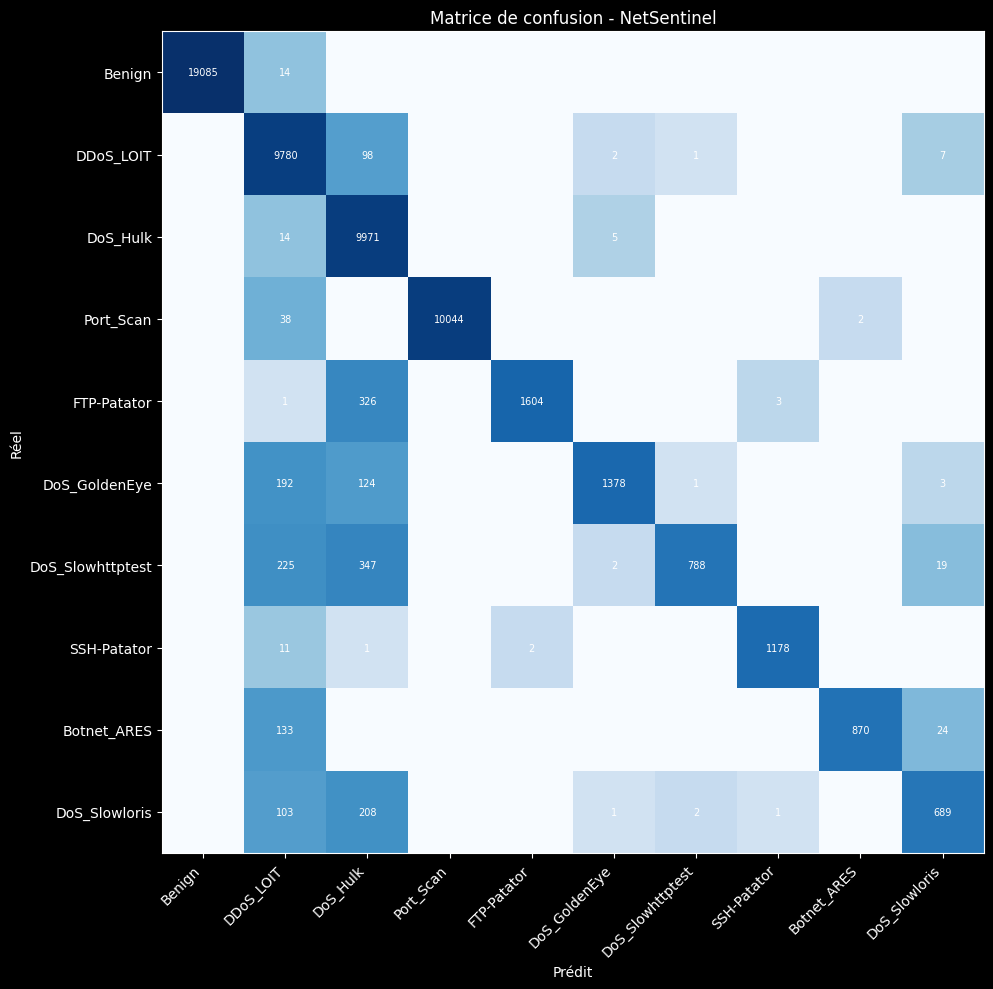

In [20]:
# Matrice de confusion

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

label_names = ["Benign", "DDoS_LOIT", "DoS_Hulk", "Port_Scan",
               "FTP-Patator", "DoS_GoldenEye", "DoS_Slowhttptest",
               "SSH-Patator", "Botnet_ARES", "DoS_Slowloris"]

matrix = np.zeros((10, 10), dtype=int)
for _, row in conf_df.iterrows():
    i = int(row["label_index"])
    j = int(row["prediction"])
    matrix[i][j] = int(row["count"])

matrix_plot = np.where(matrix == 0, 0.1, matrix)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(matrix_plot, cmap="Blues", norm=LogNorm())
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(label_names, rotation=45, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion - NetSentinel")

for i in range(10):
    for j in range(10):
        if matrix[i][j] > 0:
            ax.text(j, i, str(matrix[i][j]), ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=150)
plt.show()
plt.close()